In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [2]:
df_tree = pd.read_csv("complated_clean_data.csv")

In [3]:
df_tree.head(5)

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,0.876693,1.989608,1.008484,0.925295,-0.038259,-1.447797,-1.108065,-0.948655,0.303668,35154898
1,1.238767,1.230524,1.008484,-0.704701,0.619638,-0.330404,0.902474,1.054124,-0.664835,26710893
2,-1.155940,-0.287644,0.106553,-0.355416,-1.354054,2.282091,-1.108065,1.054124,-0.093667,11216242
3,0.109526,0.471440,0.106553,0.284939,0.525653,-0.141549,-1.108065,-0.948655,-0.471135,21984310
4,0.064715,0.471440,1.008484,2.031364,0.995579,-1.825507,-1.108065,1.054124,-0.193000,25080429


In [4]:
x = df_tree.drop('house_price_inr',axis=1)
y = df_tree['house_price_inr']

In [5]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
len(x_train)

2871

In [8]:
len(x_test)

718

In [9]:
dct_model = DecisionTreeRegressor(max_depth=15,min_samples_leaf=15,min_samples_split=20)

In [10]:
dct_model.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [11]:
p_test = dct_model.predict(x_test) 

In [12]:
result = pd.DataFrame({
    'accual_values_price' : y_test.values,
    'predicted_house_price' : p_test
})

result

,accual_values_price,predicted_house_price
0,32691574,2.957156e+07
1,25525240,2.750458e+07
2,22740225,1.822094e+07
3,12718440,1.412881e+07
4,20657437,2.432948e+07
...,...,...
713,16954740,1.648551e+07
714,13520657,1.240040e+07
715,19403671,1.806135e+07
716,4225646,4.055890e+06


In [13]:
score = r2_score(y_test,p_test) * 100
print(f"r2 score : {score}")

r2 score : 90.38910382608634


In [14]:
p_train = dct_model.predict(x_train) 

In [15]:
result = pd.DataFrame({
    'accual_values_price' : y_train.values,
    'predicted_house_price' : p_train
})

result

,accual_values_price,predicted_house_price
0,11996712,1.155711e+07
1,17020376,1.582359e+07
2,35531361,3.309146e+07
3,12257583,1.168043e+07
4,15698338,1.648551e+07
...,...,...
2866,26365052,2.957156e+07
2867,28146348,2.936397e+07
2868,34377748,3.309146e+07
2869,18941578,1.882107e+07


In [16]:
score_train = r2_score(y_train,p_train) * 100
print(f"r2 score : {score_train}")

r2 score : 93.52878022076656


In [17]:
mae = mean_absolute_error(y_test,p_test)
print(f"mean absolute error : {mae}")

mean absolute error : 1919489.7102795776


In [18]:
mse = mean_squared_error(y_test,p_test)
print(f"mean squared error : {mse}")

mean squared error : 6276877760903.011


In [19]:
kf = KFold(n_splits=5,random_state=42,shuffle=True)

In [20]:
cross_score = cross_val_score(dct_model,x,y,cv=kf,scoring='r2')

In [21]:
print(cross_score)

[0.90389104 0.89677829 0.90521934 0.90131607 0.89918631]


In [22]:
avg_score = cross_score.mean()
print(f"Avrage score : {avg_score}")

Avrage score : 0.9012782077122836


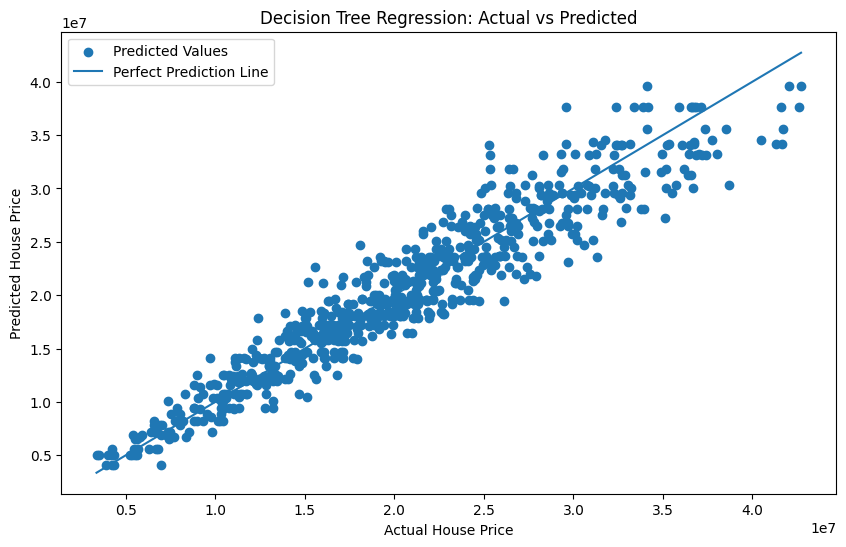

In [23]:
# =====================================
# Decision Tree Final Performance Graph
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    p_test,
    label='Predicted Values'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    label='Perfect Prediction Line'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.legend()

plt.show()

## Decision Tree Graph Interpretation

### Graph Analysis: Actual vs Predicted House Price

The graph above represents the relationship between the **actual house prices** and the **predicted house prices** generated by the Decision Tree Regression model.

### Observation

- Most of the prediction points are located close to the **Perfect Prediction Line**.
- A smaller distance between points and the diagonal line indicates lower prediction error.
- The points follow a strong positive linear pattern, showing that the model predicts house prices effectively.
- A few points are slightly distant from the line, which represents minor prediction deviations.

### Interpretation

The Decision Tree Regression model demonstrates strong predictive performance because the predicted values closely follow the actual values. The visual pattern indicates that the model successfully captures the relationship between the input features and house prices.

### Conclusion

✅ Predictions are closely aligned with actual values  
✅ Low prediction error observed  
✅ Low overfitting detected  
✅ Good generalization performance  

Therefore, the Decision Tree Regression model can be considered a **good and reliable model for house price prediction**.

# Final Conclusion – Decision Tree Regression

| Metric | Value | Interpretation |
|----------|--------|----------------|
| Training R² Score | 93.53% | Model learned training data effectively |
| Testing R² Score | 90.39% | Strong prediction performance on unseen data |
| Average Cross Validation Score | 90.13% | Stable model performance across folds |
| MAE | 1,919,489.71 | Average prediction error |
| MSE | 6,276,877,760,903.01 | Squared prediction error |
| Train-Test Difference | 3.14% | Small difference indicates low overfitting |
| Model Performance | Very Good |
| Overfitting Status | Low |

## Model Status

✅ Good Model  
❌ Worst Model: No

## Final Business Conclusion

The Decision Tree Regression model achieved a training score of **93.53%** and a testing score of **90.39%**. The average cross-validation score of **90.13%** indicates stable and reliable performance across multiple folds. Since the difference between training and testing scores is only **3.14%**, the model shows low overfitting and good generalization ability. Therefore, the Decision Tree model can be considered a reliable and effective model for house price prediction on unseen data.